<a href="https://colab.research.google.com/github/hotsard/2026_bigdata_computing_class/blob/main/2%EC%B0%A8%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install pyngrok -q
!pip install pyngrok streamlit scikit-learn joblib -q

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from pyngrok import ngrok
from sklearn.metrics import mean_squared_error, r2_score


url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url).dropna()
df.columns = df.columns.str.strip()


features = ['Adult mortality', 'BMI', 'GDP']
X = df[features]
y = df['Life expectancy']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_sample = X_train_full.sample(n=50, random_state=42)
X_train = train_sample
y_train = y_train_full.loc[train_sample.index]

model1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

model2_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

model3_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

model1_pipe.fit(X_train, y_train)
model2_pipe.fit(X_train, y_train)
model3_pipe.fit(X_train, y_train)


joblib.dump(model1_pipe, 'model1_linear.pkl')
joblib.dump(model2_pipe, 'model2_poly.pkl')
joblib.dump(model3_pipe, 'model3_ridge.pkl')


joblib.dump((X_train, y_train, X_test, y_test), 'data_split.pkl')

print("1단계: 모델 학습 및 .pkl 파일 저장 완료")


1단계: 모델 학습 및 .pkl 파일 저장 완료


In [31]:
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error

st.set_page_config(layout="wide")
st.title("기대수명 예측 및 모델 성능 비교")

m1 = joblib.load('model1_linear.pkl')
m2 = joblib.load('model2_poly.pkl')
m3 = joblib.load('model3_ridge.pkl')
X_train, y_train, X_test, y_test = joblib.load('data_split.pkl')


X_train.columns = X_train.columns.str.strip()
X_test.columns = X_test.columns.str.strip()

models = {'Linear': m1, 'Poly': m2, 'Ridge': m3}
st.header("1. 모델별 성능 비교 분석")

metrics_list = []
for name, model in models.items():
    if 'poly' in model.named_steps:
        complexity = model.named_steps['poly'].n_output_features_
    else:
        complexity = X_train.shape[1]

    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, model.predict(X_test))

    metrics_list.append({
        'Model': name,
        'Complexity': complexity,
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'Train MSE': round(train_mse, 4),
        'Test MSE': round(test_mse, 4)
    })

df_metrics = pd.DataFrame(metrics_list).set_index('Model')


col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("성능 평가지표 결과")
    st.dataframe(df_metrics, use_container_width=True)

with col2:
    st.subheader("Test R² 점수 시각화")
    fig, ax = plt.subplots(figsize=(6, 3.8))
    sns.barplot(x=df_metrics.index, y=df_metrics['Test R²'], palette='Set2', ax=ax)
    ax.set_ylabel("Test R² Score")
    ax.set_ylim(-1, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    st.pyplot(fig)

st.markdown("---")


st.header(" 2. 실시간 기대수명 동적 예측")

# 사이드바 입력 창 구성 (이제 컬럼을 정확하게 매핑합니다)
st.sidebar.header("독립변수 입력 슬라이더")
input_mortality = st.sidebar.slider("Adult Mortality (성인 사망률)", int(X_train['Adult mortality'].min()), int(X_train['Adult mortality'].max()), int(X_train['Adult mortality'].mean()))
input_bmi = st.sidebar.slider("BMI (체질량지수)", float(X_train['BMI'].min()), float(X_train['BMI'].max()), float(X_train['BMI'].mean()))
input_gdp = st.sidebar.slider("GDP (1인당 국내총생산)", int(X_train['GDP'].min()), int(X_train['GDP'].max()), int(X_train['GDP'].mean()))

# 모델 선택 인터페이스
selected_model_name = st.selectbox("분석 및 예측에 사용할 회귀 모델을 선택하세요:", ['Linear', 'Poly', 'Ridge'])
selected_model = models[selected_model_name]

# 실시간 동적 예측 데이터프레임 구성
input_data = pd.DataFrame([[input_mortality, input_bmi, input_gdp]], columns=['Adult mortality', 'BMI', 'GDP'])

# 실시간 동적 예측 결과 출력
prediction = selected_model.predict(input_data)[0]

st.subheader(f"[{selected_model_name}] 모델 예측 결과")
st.markdown(f"<h1 style='text-align: center; color: #1E88E5; font-size: 50px;'>예측된 기대수명: {prediction:.2f} 세</h1>", unsafe_allow_html=True)
"""

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✓ app.py 파일 수정 및 생성 완료!")

✓ app.py 파일 수정 및 생성 완료!


In [30]:
# =====================================================================
# [조건 5] ngrok 터널링을 통한 공인 웹 서비스 배포
# =====================================================================

# 백그라운드에서 스트림릿 서버 구동
os.system("streamlit run app.py --server.port 8501 &")

# !!! [필수] 본인의 ngrok Authtoken을 입력하셔야 정상 작동합니다 !!!
# ngrok 홈페이지(https://dashboard.ngrok.com) 가입 후 토큰을 복사해 넣으세요.
NGROK_TOKEN = "3EFigzE4KO0aSSGhK6duXUojLH1_53eWv2MKurEcnd4bjC9iG"
ngrok.set_auth_token(NGROK_TOKEN)

# 8501 포트 터널링 열기
public_url = ngrok.connect(8501, proto="http")
print("\n" + "="*60)
print(f" 웹 대시보드가 성공적으로 배포되었습니다!")
print(f" Public URL: {public_url.public_url}")
print("="*60)


 웹 대시보드가 성공적으로 배포되었습니다!
 Public URL: https://wafer-refreeze-cesarean.ngrok-free.dev


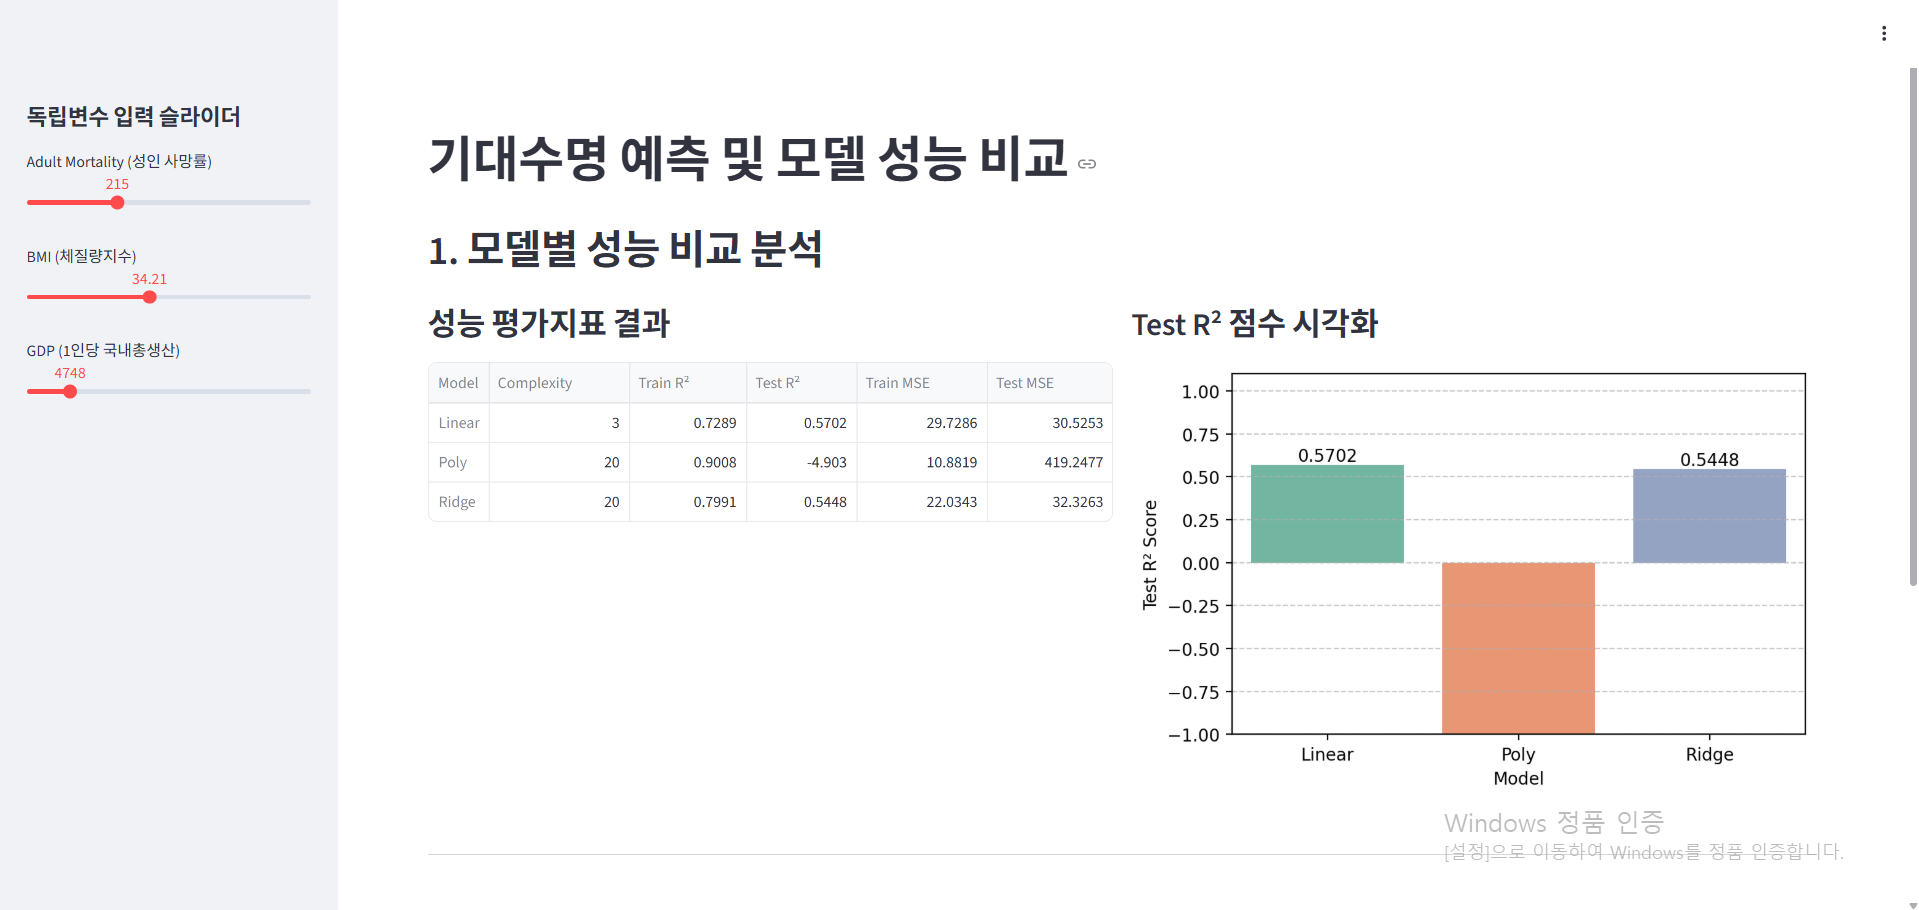

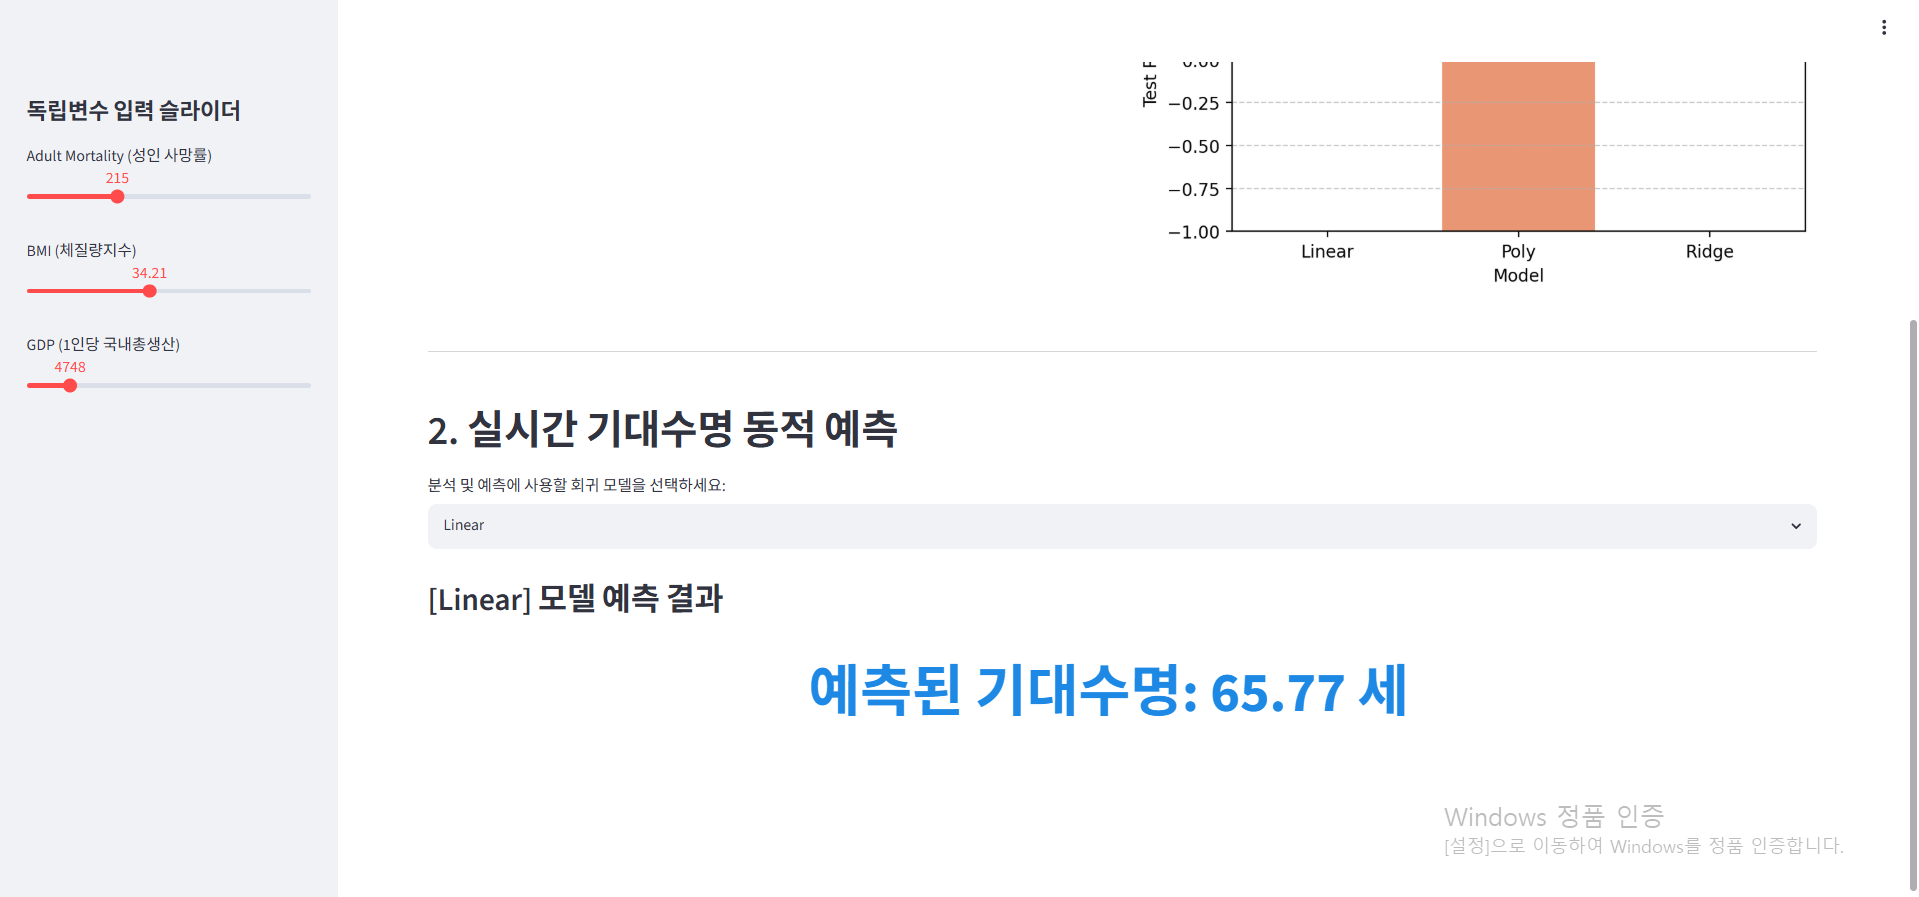

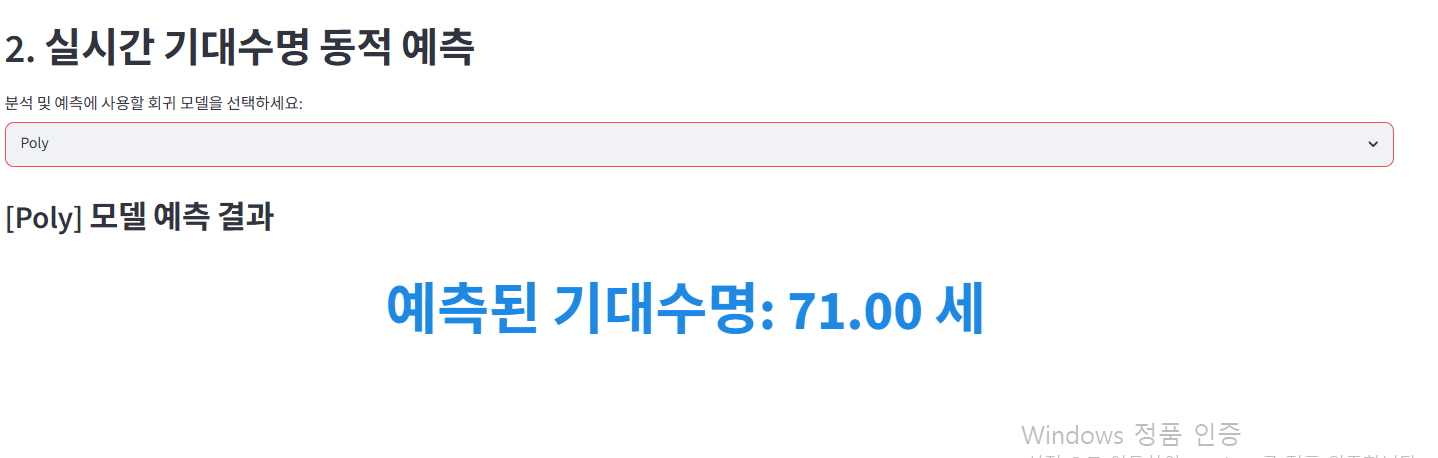

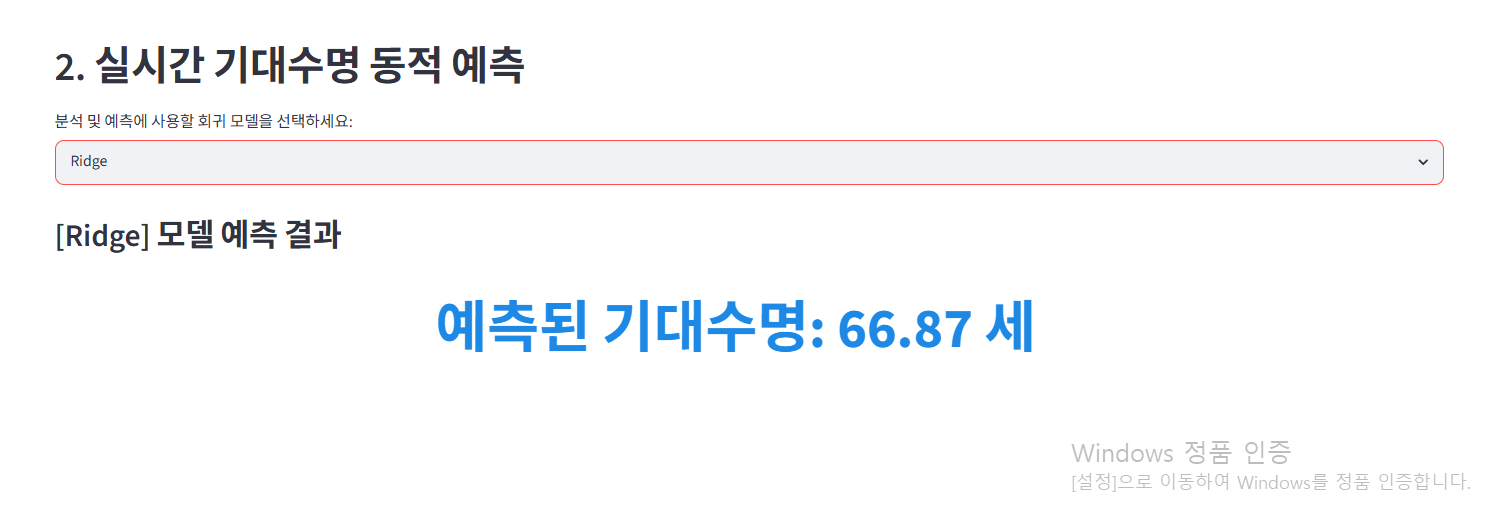